In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r'C:\Users\Pravalika.b\Downloads\churn.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
print('rows and columns:',df.shape)
df.info()

rows and columns: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Check churn distribution

In [6]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

### Overall churn rate

In [7]:
churn_rate=df['Exited'].mean() * 100
print(f'overall churn rate:{churn_rate:.2f}%')

overall churn rate:20.37%


### Churn percentage

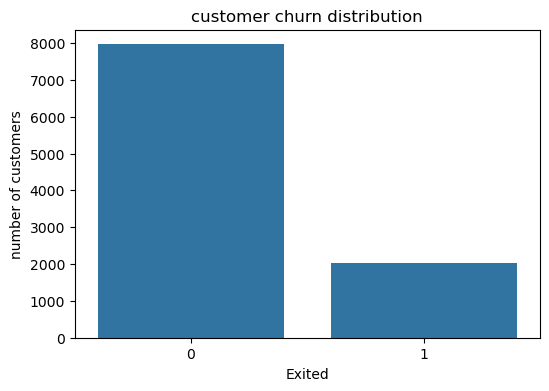

In [10]:
churn_counts=df['Exited'].value_counts()
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Exited')
plt.title("customer churn distribution")
plt.xlabel("Exited")
plt.ylabel("number of customers")
plt.show()

### churn by Geography

In [11]:
geo_churn=df.groupby("Geography")["Exited"].mean()*100
print(geo_churn)

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64


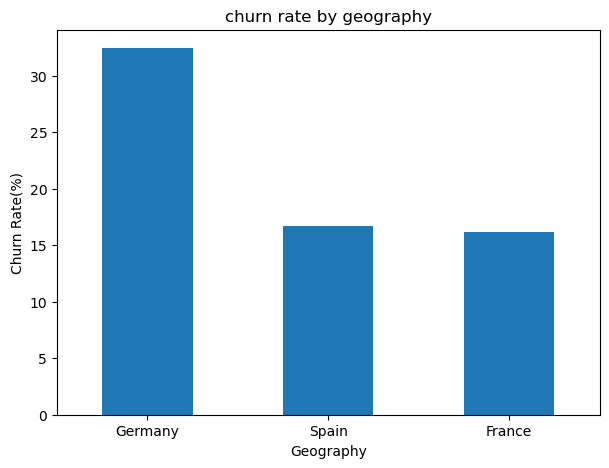

In [13]:
plt.figure(figsize=(7,5))
geo_churn.sort_values(ascending=False).plot(kind='bar')
plt.title("churn rate by geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### churn by gender

In [15]:
gender_churn=df.groupby('Gender')['Exited'].mean()*100
print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


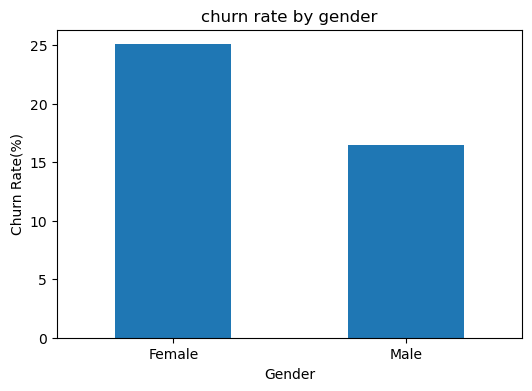

In [16]:
plt.figure(figsize=(6,4))
gender_churn.plot(kind='bar')
plt.title("churn rate by gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### create age groups

In [19]:
df['AgeGroup']=pd.cut(
    df['Age'],
    bins=[0,25,35,45,55,100],
    labels=['18-25','26-35','36-45','46-55','56+']
            )


In [21]:
age_churn=df.groupby("AgeGroup",observed=True)['Exited'].mean()*100
age_churn

AgeGroup
18-25     7.528642
26-35     8.498024
36-45    19.619914
46-55    50.572082
56+      36.750000
Name: Exited, dtype: float64

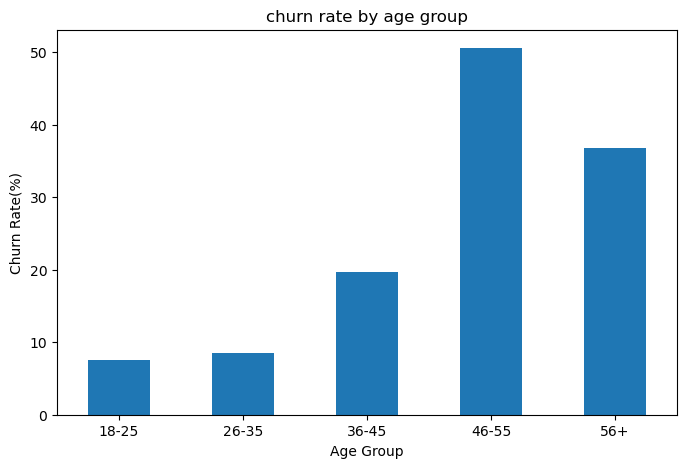

In [22]:
plt.figure(figsize=(8,5))
age_churn.plot(kind='bar')
plt.title("churn rate by age group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### Churn by credit score

In [23]:
df['CreditScoreGroup']=pd.cut(
    df['CreditScore'],
    bins=[0,580,670,740,800,900],
    labels=["Poor","Fair","Good","Very Good","Excellent"]
)
          

In [26]:
credit_churn=df.groupby(
    "CreditScoreGroup",
    observed=True
) ['Exited'].mean()*100
print(credit_churn)

CreditScoreGroup
Poor         22.147931
Fair         20.388060
Good         18.815186
Very Good    20.246914
Excellent    19.689922
Name: Exited, dtype: float64


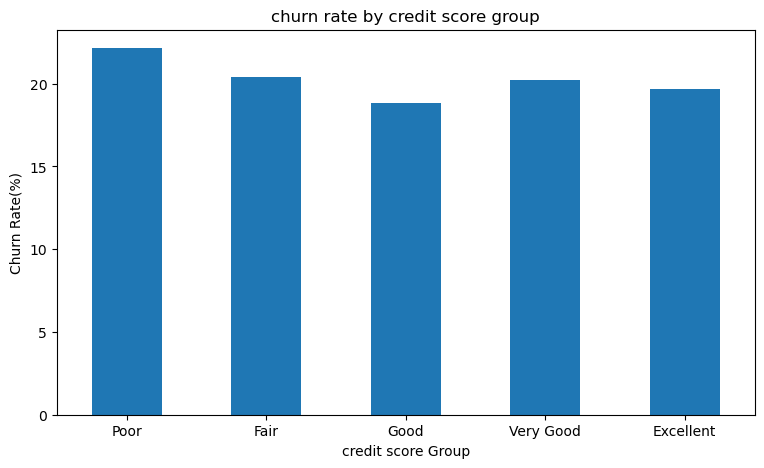

In [27]:
plt.figure(figsize=(9,5))
credit_churn.plot(kind='bar')
plt.title("churn rate by credit score group")
plt.xlabel("credit score Group")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### churn by tenure

In [28]:
tenure_churn=df.groupby("Tenure")['Exited'].mean()*100
print(tenure_churn)


Tenure
0     23.002421
1     22.415459
2     19.179389
3     21.110010
4     20.525784
5     20.652174
6     20.268873
7     17.217899
8     19.219512
9     21.646341
10    20.612245
Name: Exited, dtype: float64


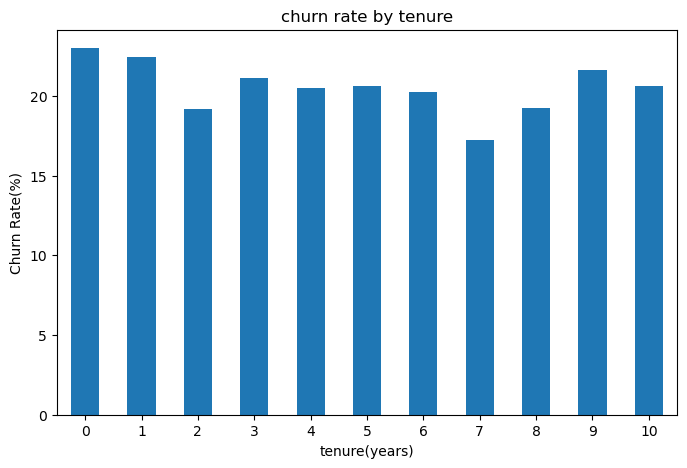

In [29]:
plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar')
plt.title("churn rate by tenure")
plt.xlabel("tenure(years)")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### churn by number of products

In [31]:
product_churn=df.groupby("NumOfProducts")['Exited'].mean()*100
print(product_churn)

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


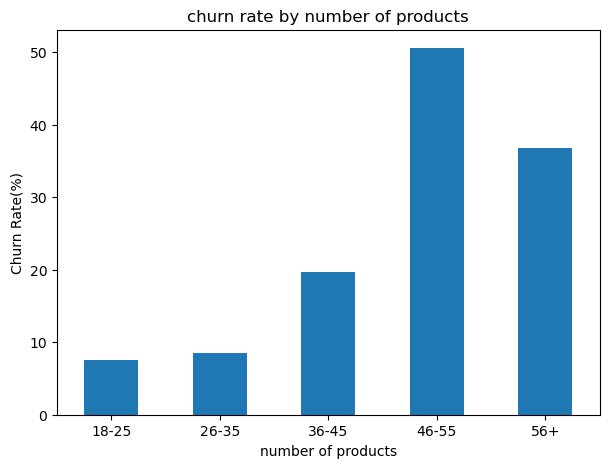

In [32]:
plt.figure(figsize=(7,5))
age_churn.plot(kind='bar')
plt.title("churn rate by number of products")
plt.xlabel("number of products")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### churn by active membership

In [34]:
active_churn=df.groupby('IsActiveMember')['Exited'].mean()*100
print(active_churn)


IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


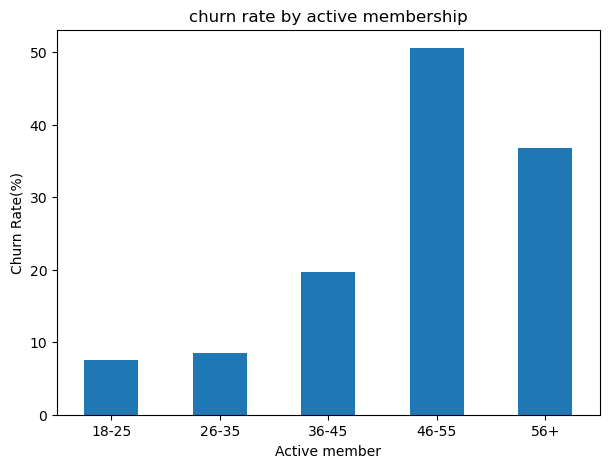

In [35]:
plt.figure(figsize=(7,5))
age_churn.plot(kind='bar')
plt.title("churn rate by active membership")
plt.xlabel("Active member")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### churn by credir card

In [37]:
card_churn=df.groupby('HasCrCard')['Exited'].mean()*100
print(card_churn)

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64


### churn by balance

In [38]:
df['BalanceGroup']=pd.cut(
    df['Balance'],
    bins=[-1,50000,100000,150000,250000],
    labels=['Low','Medium','High','Very High']
)

In [39]:
balance_churn=df.groupby(
    'BalanceGroup',
    observed=True
)['Exited'].mean()*100
print(balance_churn)

BalanceGroup
Low          14.247021
Medium       19.880716
High         25.770235
Very High    23.037190
Name: Exited, dtype: float64


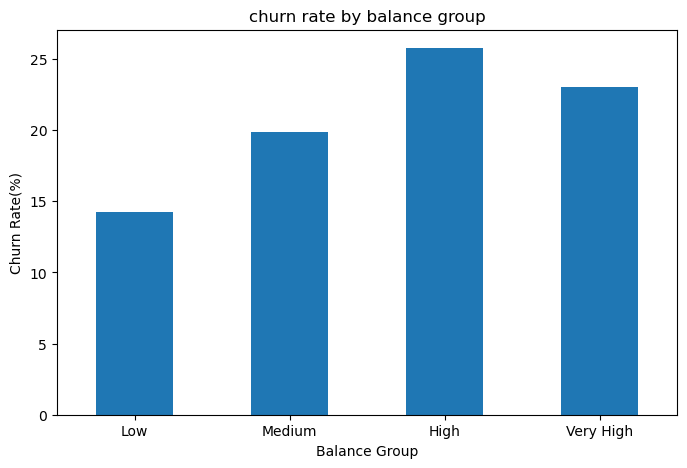

In [40]:
plt.figure(figsize=(8,5))
balance_churn.plot(kind='bar')
plt.title("churn rate by balance group")
plt.xlabel("Balance Group")
plt.ylabel("Churn Rate(%)")
plt.xticks(rotation=0)
plt.show()

### correlation analysis

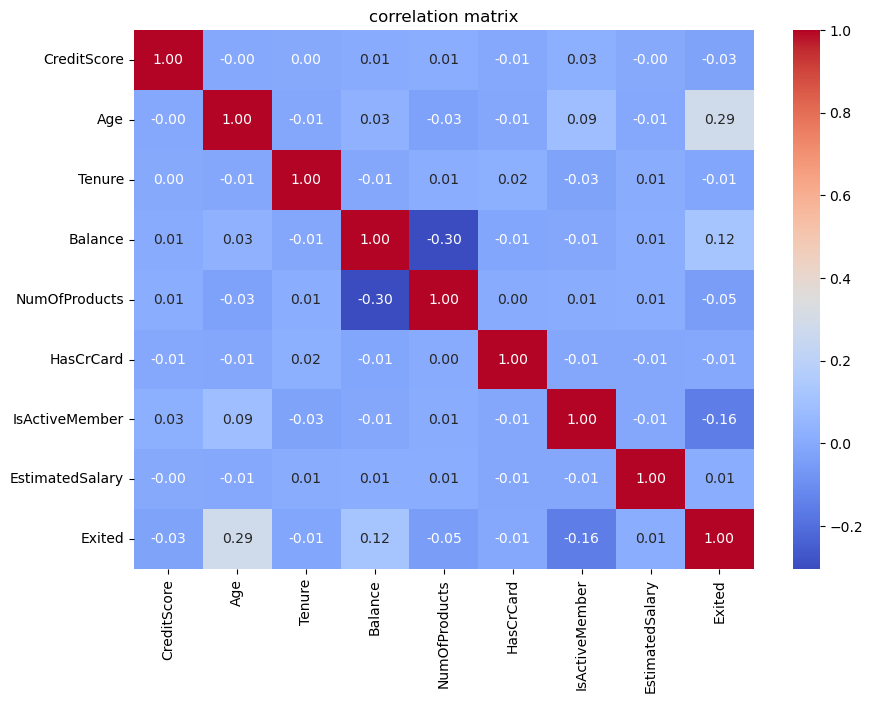

In [46]:
numeric_cols=[
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary",
    "Exited"
]
correlation=df[numeric_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation matrix')
plt.show()

### show correlation with churn

In [47]:
churn_correlation=correlation['Exited'].sort_values(ascending=False)
print(churn_correlation)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


### find high-risk customer segments

In [48]:
high_risk=df[
(df['Age']>=45)&
(df['IsActiveMember']==0)&
(df['Exited']==1)
]
print('high-risk churned customers:',len(high_risk))

high-risk churned customers: 673


In [49]:
segment=df.groupby(
    ['Geography','IsActiveMember']
)['Exited'].mean()*100
print(segment.sort_values(ascending=False))

Geography  IsActiveMember
Germany    0                 41.078509
           1                 23.717949
Spain      0                 23.347639
France     0                 21.130830
           1                 11.501351
Spain      1                 10.746951
Name: Exited, dtype: float64


### find the highese-risk segments automatically

In [55]:
segments=(
    df.groupby(['Geography','Gender','IsActiveMember'])['Exited']
.agg(['count','mean'])
.reset_index()
)
segments['ChurnRate']=segments['mean']*100
segments=segments.sort_values(
    'ChurnRate',
    ascending=False
)
segments.head(10)

,Geography,Gender,IsActiveMember,count,mean,ChurnRate
4,Germany,Female,0,634,0.446372,44.637224
6,Germany,Male,0,627,0.374801,37.480064
5,Germany,Female,1,559,0.295170,29.516995
8,Spain,Female,0,526,0.292776,29.277567
0,France,Female,0,1099,0.262056,26.205641
7,Germany,Male,1,689,0.190131,19.013062
10,Spain,Male,0,639,0.184664,18.466354
2,France,Male,0,1324,0.169184,16.918429
1,France,Female,1,1162,0.148021,14.802065
9,Spain,Female,1,563,0.136767,13.676732


### create a summary table

In [57]:
summary=pd.DataFrame({
    'Metric':[
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Overall Churn Rate"
    ],
    "value":[
        len(df),
        df['Exited'].sum(),
        (df['Exited']==0).sum(),
         f"{df['Exited'].mean()*100:.2f}%"
         ]
})
print(summary)
        

               Metric   value
0     Total Customers   10000
1   Churned Customers    2037
2  Retained Customers    7963
3  Overall Churn Rate  20.37%


### Five retention recommendations
1. Focus retention campaigns on inactive customers because they show higher churn risk.
2. Provide loyality benefits and personalized offers to high-risk  customers.
3. Pay special attention to older customers if their churn rate is high.
4. Investigate customers with multiple products if this segment shows elevated churn.
5. Prioritize high-value/high-balance customers who show a high probability of churn.